# New York Outdoor Dining — Data Exploration

This notebook documents the full data pipeline for the thesis project:
from raw NYC Open Data to a clean, labeled dataset ready for modeling.

> *Outdoor dining is still there — just not in most parts of the city.*

The goal is not prediction. The goal is to understand whether the spatial pattern
found in the thesis can be associated with measurable conditions.

---

## Data sources

| File | Source | Role |
|------|--------|------|
| `Open_Restaurant_Applications_(Historic)_20260307.csv` | NYC Open Data | Historic peak locations (raw) |
| `Dining_Out_NYC_Locations.csv` | NYC Open Data | Current licensed locations (raw) |
| `MTA_Subway_Stations_20260405.geojson` | MTA / NYC Open Data | Transit distance calculation |
| `311_Service_Requests...geojson` | NYC Open Data | Complaint data (friction proxy) |
| `thesis_points_final_v2.geojson` | Derived (this project) | Current locations with all features pre-computed |

**Note on `thesis_points_final_v2.geojson`:**  
This file was produced by a separate spatial pipeline that joined current dining locations
with MTA station distances, 311 complaint counts, and DBSCAN clustering.
It is used here as-is for the current-condition analysis (Section 2a).
The raw-to-derived process for the historic dataset is shown in Section 1.

## Setup

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [2]:
import json
import math
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

---
## 1. Load and Clean Raw Data

### 1a. Historic locations (raw CSV → cleaned DataFrame)

Source: `Open_Restaurant_Applications_(Historic)_20260307.csv`  
14,428 rows across all 5 boroughs. We filter to Manhattan and deduplicate by coordinate.

This section prepares the historic dataset by filtering to Manhattan and removing duplicate coordinates.

In [3]:
## 1a. Load Dataset — Historic (raw)

historic_raw_df = pd.read_csv('data/Open_Restaurant_Applications_(Historic)_20260307.csv')

print(f'Raw historic: {len(historic_raw_df):,} rows')
print(f'Boroughs: {historic_raw_df["Borough"].value_counts().to_dict()}')
print(f'Columns: {list(historic_raw_df.columns[:6])}...')
historic_raw_df.head(3)

Raw historic: 14,428 rows
Boroughs: {'Manhattan': 7179, 'Brooklyn': 3548, 'Queens': 2751, 'Bronx': 747, 'Staten Island': 203}
Columns: ['objectid', 'globalid', 'Seating Interest (Sidewalk/Roadway/Both)', 'Restaurant Name', 'Legal Business Name', 'Doing Business As (DBA)']...


,objectid,globalid,Seating Interest (Sidewalk/Roadway/Both),Restaurant Name,Legal Business Name,Doing Business As (DBA),Building Number,Street,Borough,Postcode,...,healthCompliance_terms,Time of Submission,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA
0,100,c4b3155b-31a0-4e95-846f-fce09f245437,sidewalk,Pomp and Circumstance Hospitality,Pomp and Circumstance Hospitality LLC,Pomp and Circumstance Hospitality LLC,577,Lorimer Street,Brooklyn,11211,...,yes,06/19/2020 11:04:00 AM,40.714264,-73.949416,1.0,34.0,501.0,3068653.0,3.027560e+09,East Williamsburg
1,1000,753495d8-4429-43e5-85a3-dcf6230ef749,both,Charm Kao,193 Schemerhorn INC,Charm Kao,193,Schermerhorn St.,Brooklyn,11201,...,yes,06/19/2020 02:35:00 PM,40.689107,-73.986352,2.0,33.0,37.0,3000493.0,3.001640e+09,DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hill
2,10000,{3842B5C5-EF04-41A4-8216-D6EA627DCE5E},openstreets,SAKE BAR HAGI 46,"HAMA NEW YORK, INC.",SAKE BAR HAGI 46,358,W. 46TH STREET,Manhattan,10036,...,yes,08/07/2020 01:28:00 PM,40.760463,-73.989528,4.0,3.0,121.0,1025025.0,1.010360e+09,Clinton


In [4]:
# Filter: Manhattan only, valid coordinates
hist_manh_df = historic_raw_df[
    (historic_raw_df['Borough'] == 'Manhattan') &
    (historic_raw_df['Latitude'].notna()) &
    (historic_raw_df['Longitude'].notna()) &
    (historic_raw_df['Latitude'].astype(float) > 40.68) &
    (historic_raw_df['Latitude'].astype(float) < 40.88) &
    (historic_raw_df['Longitude'].astype(float) > -74.03) &
    (historic_raw_df['Longitude'].astype(float) < -73.90)
].copy()

print(f'Manhattan with coords: {len(hist_manh_df):,}')

# Deduplicate by coordinate (round to 5 decimal places ~1m precision)
hist_manh_df['lat_r'] = hist_manh_df['Latitude'].round(5)
hist_manh_df['lon_r'] = hist_manh_df['Longitude'].round(5)
hist_manh_df = hist_manh_df.drop_duplicates(subset=['lat_r', 'lon_r'])

print(f'After coord dedup:     {len(hist_manh_df):,}')
print(f'Removed as duplicates: {6471 - len(hist_manh_df):,}')

Manhattan with coords: 6,467
After coord dedup:     4,659
Removed as duplicates: 1,812


In [5]:
# Missing values in key columns
print('Missing values (Manhattan historic):')
print(hist_manh_df[['Latitude', 'Longitude', 'Street', 'Seating Interest (Sidewalk/Roadway/Both)']].isnull().sum())

# Seating type distribution
print('\nSeating interest:')
print(hist_manh_df['Seating Interest (Sidewalk/Roadway/Both)'].value_counts())

Missing values (Manhattan historic):
Latitude                                    0
Longitude                                   0
Street                                      0
Seating Interest (Sidewalk/Roadway/Both)    0
dtype: int64

Seating interest:
Seating Interest (Sidewalk/Roadway/Both)
both           2295
sidewalk       1605
roadway         698
openstreets      61
Name: count, dtype: int64


In [6]:
# Keep only what we need — assign survived=0
hist_clean_df = hist_manh_df[['lat_r', 'lon_r', 'Street']].copy()
hist_clean_df.columns = ['lat', 'lon', 'street_name']
hist_clean_df['survived'] = 0
hist_clean_df['street_name'] = hist_clean_df['street_name'].fillna('').str.upper().str.strip()

print(f'Historic clean: {len(hist_clean_df):,} rows')
hist_clean_df.head(3)

Historic clean: 4,659 rows


,lat,lon,street_name,survived
2,40.76046,-73.98953,W. 46TH STREET,0
3,40.76108,-73.99068,9AVE,0
5,40.70402,-74.01020,PEARL STREET,0


### 1b. Current locations (raw CSV → cleaned DataFrame)

Source: `Dining_Out_NYC_Locations.csv`  
595 rows across all boroughs, all with active licenses.

This section prepares the current licensed dataset and normalizes street names for comparison.

In [7]:
## 1b. Load Dataset — Current (raw)

current_raw_df = pd.read_csv('data/Dining_Out_NYC_Locations.csv')

print(f'Raw current: {len(current_raw_df):,} rows')
print(f'Boroughs: {current_raw_df["Borough"].value_counts().to_dict()}')
print(f'License types: {current_raw_df["License Type"].value_counts().to_dict()}')
current_raw_df.head(3)

Raw current: 595 rows
Boroughs: {'Manhattan': 358, 'Brooklyn': 196, 'Queens': 32, 'Bronx': 8, 'Staten Island': 1}
License types: {'Roadway': 390, 'Sidewalk': 205}


,Business Legal Name,Assumed Name(s),Street,City,Borough,Postcode,License Type,License Status,License Issue Date,License Expiration Date,Latitude,Longitude,Council District,Community Board,BIN,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),Location
0,"TERROIR TRIBECA, LLC",TERROIR TRIBECA,24 HARRISON STREET,NEW YORK,Manhattan,10013,Sidewalk,Issued,02/13/2026 03:37:42 PM,02/13/2030 11:59:59 PM,40.718766,-74.010032,1,101,1002082.0,1.001810e+09,39,MN0102,POINT (-74.010032397316 40.718766008443)
1,"AMITY STREET, INC.",AMITY HALL,80 WEST 3 STREET,NEW YORK,Manhattan,10012,Roadway,Issued,07/18/2025 02:48:40 PM,07/18/2029 11:59:59 PM,40.729756,-73.998784,2,102,1008675.0,1.005390e+09,65,MN0202,POINT (-73.998784078515 40.729756486478)
2,THE CRYSTAL ROOM LP,BLUE RIBBON BRASSERIE,97 SULLIVAN STREET,NEW YORK,Manhattan,10012,Roadway,Issued,07/18/2025 02:55:29 PM,07/18/2029 11:59:59 PM,40.725524,-74.003135,1,102,1007775.0,1.005030e+09,49,MN0201,POINT (-74.003135217816 40.725524021007)


In [8]:
# Filter: Manhattan only, valid coordinates
curr_manh_df = current_raw_df[
    (current_raw_df['Borough'] == 'Manhattan') &
    (current_raw_df['Latitude'].notna()) &
    (current_raw_df['Longitude'].notna())
].copy()

print(f'Manhattan with coords: {len(curr_manh_df):,}')

# Deduplicate by coordinate
curr_manh_df['lat_r'] = curr_manh_df['Latitude'].round(5)
curr_manh_df['lon_r'] = curr_manh_df['Longitude'].round(5)
curr_manh_df = curr_manh_df.drop_duplicates(subset=['lat_r', 'lon_r'])
print(f'After coord dedup: {len(curr_manh_df):,}')

# Keep only what we need — assign survived=1
import re
curr_clean_df = curr_manh_df[['Latitude', 'Longitude', 'Street']].copy()
curr_clean_df.columns = ['lat', 'lon', 'street_name']
curr_clean_df['survived'] = 1
curr_clean_df['street_name'] = curr_clean_df['street_name'].fillna('').str.upper().str.strip()

# Remove leading street number (e.g., "167 MULBERRY STREET" → "MULBERRY STREET")
curr_clean_df['street_name'] = curr_clean_df['street_name'].apply(
    lambda s: re.sub(r'^\d+\s+', '', s).strip()
)

print(f'Current clean: {len(curr_clean_df):,} rows')
curr_clean_df.head(3)

Manhattan with coords: 358
After coord dedup: 318
Current clean: 318 rows


,lat,lon,street_name,survived
0,40.718766,-74.010032,HARRISON STREET,1
1,40.729756,-73.998784,WEST 3 STREET,1
2,40.725524,-74.003135,SULLIVAN STREET,1


In [9]:
curr_clean_df['street_name'].value_counts().head(10)

street_name
AMSTERDAM AVENUE    18
2 AVENUE            15
MULBERRY STREET     13
COLUMBUS AVENUE     13
8 AVENUE             7
1 AVENUE             7
9 AVENUE             6
GREENWICH AVENUE     6
BLEECKER STREET      6
CANAL STREET         6
Name: count, dtype: int64

### 1c. Combine into ML dataset

The two datasets are combined into one binary classification table, where survived is the target.

In [10]:
# Combine historic (survived=0) + current (survived=1)
dining_df = pd.concat([hist_clean_df, curr_clean_df], ignore_index=True)

print(f'Combined ML dataset: {len(dining_df):,} rows')
print(f'\nClass distribution:')
print(dining_df['survived'].value_counts())
print(f'\nClass imbalance: 1:{dining_df[dining_df.survived==0].shape[0] // dining_df[dining_df.survived==1].shape[0]}')

dining_df.head(3)

Combined ML dataset: 4,977 rows

Class distribution:
survived
0    4659
1     318
Name: count, dtype: int64

Class imbalance: 1:14


,lat,lon,street_name,survived
0,40.76046,-73.98953,W. 46TH STREET,0
1,40.76108,-73.99068,9AVE,0
2,40.70402,-74.01020,PEARL STREET,0


### 1d. Add transit distance feature

Join MTA subway stations to compute distance from each location to its nearest station.  
Threshold: 400m (Jan Gehl 5-minute walk standard).

Transit distance is added as a proxy for accessibility.

In [11]:
# Load MTA stations
with open('data/MTA_Subway_Stations_20260405.geojson') as f:
    mta_gj = json.load(f)

mta_feats = [f for f in mta_gj['features']
             if f['properties']['borough'] == 'M']
print(f'MTA Manhattan stations: {len(mta_feats)}')

# Build KDTree from station coordinates
LAT_M = 111320
LON_M = 111320 * math.cos(math.radians(40.75))

station_coords = np.array([
    [float(f['properties']['gtfs_latitude'])  * LAT_M,
     float(f['properties']['gtfs_longitude']) * LON_M]
    for f in mta_feats
])
tree = cKDTree(station_coords)

# Compute distance for all dining locations
dining_coords = np.array([
    [row['lat'] * LAT_M, row['lon'] * LON_M]
    for _, row in dining_df.iterrows()
])

dists, _ = tree.query(dining_coords)
dining_df['dist_subway_m']   = dists.round(1)
dining_df['is_near_transit'] = (dists <= 400).astype(int)

print(f'\nTransit distance added:')
print(f'  median: {dining_df["dist_subway_m"].median():.0f}m')
print(f'  near transit (≤400m): {dining_df["is_near_transit"].sum():,} / {len(dining_df):,}')

MTA Manhattan stations: 153

Transit distance added:
  median: 231m
  near transit (≤400m): 4,314 / 4,977


### 1e. Add corridor feature

Locations on the top-4 repeated streets (from S4 corridor analysis) are marked as `is_corridor=1`.

In [12]:
# Top corridor streets identified in thesis S4

TOP_HISTORIC = {'2ND AVENUE', '2ND AVE', 'SECOND AVENUE',
                'AMSTERDAM AVE', 'AMSTERDAM AVENUE',
                'COLUMBUS AVE', 'COLUMBUS AVENUE',
                'MULBERRY ST', 'MULBERRY STREET'}

TOP_CURRENT  = {'2 AVENUE', '1 AVENUE', 'AMSTERDAM',
                'COLUMBUS', 'MULBERRY'}

def is_corridor(street, survived):
    s = street.upper().strip()
    if survived == 0:
        return int(s in TOP_HISTORIC)
    else:
        return int(any(top in s for top in TOP_CURRENT))

dining_df['is_corridor'] = dining_df.apply(
    lambda row: is_corridor(row['street_name'], row['survived']), axis=1
)

print(f'is_corridor=1: {dining_df["is_corridor"].sum()} locations')
print(f'  survived=1: {dining_df[dining_df.survived==1]["is_corridor"].sum()}')
print(f'  survived=0: {dining_df[dining_df.survived==0]["is_corridor"].sum()}')

is_corridor=1: 362 locations
  survived=1: 67
  survived=0: 295


### 1e-bis. Add street width feature

Street width is a proxy for physical space capacity — wider streets can accommodate outdoor dining structures more comfortably alongside pedestrian and vehicle traffic.
Source: `streets_manhattan.geojson` (DOT street inventory, joined by street name).

Street width is added as a proxy for physical street capacity.

In [13]:
# Load street physical features
with open('data/streets_manhattan.geojson') as f:
    streets_gj = json.load(f)

# Build street name → median width lookup
name_to_width = defaultdict(list)
for f in streets_gj['features']:
    name = (f['properties'].get('full_street_name') or '').upper().strip()
    if not name:
        continue
    try:
        w = float(f['properties'].get('streetwidth') or 0)
        if w > 0:
            name_to_width[name].append(w)
    except:
        pass

def lookup_streetwidth(street_name):
    """Lookup median street width by name. Tries exact match first, then partial."""
    s = street_name.upper().strip()
    
    # Exact match
    if s in name_to_width:
        return statistics.median(name_to_width[s])
    
    # Partial match
    for key in name_to_width:
        if s in key or key in s:
            return statistics.median(name_to_width[key])
    
    return np.nan

# Apply to dining_df
dining_df['streetwidth'] = dining_df['street_name'].apply(lookup_streetwidth)

matched = dining_df['streetwidth'].notna().sum()
print(f'Street width matched: {matched}/{len(dining_df)} ({matched/len(dining_df)*100:.1f}%)')
print(f'\nStreet width stats (feet):')
print(dining_df['streetwidth'].describe().round(1))

Street width matched: 2613/4977 (52.5%)

Street width stats (feet):
count    2613.0
mean       44.0
std        15.0
min        14.0
25%        30.0
50%        40.0
75%        60.0
max        70.0
Name: streetwidth, dtype: float64


### Note on streetwidth coverage

Street width is matched using street name and partial matching. The ~52% coverage reflects a fundamental limitation: dining locations are represented as **points** while street data are **line segments**. Not all dining points align precisely with street geometry in the dataset.

This is not a data quality issue, but rather a structural consequence of point-line spatial joining. The streetwidth analysis should be interpreted as a partial view of physical street conditions—specifically, for locations that could be successfully matched to streets with available width measurements.

More precise spatial methods (e.g., nearest street segment within 20m buffer) could improve coverage in future work.

### 1f. Dataset summary

Overview of the final ML-ready dataset before any modeling.

In [14]:
# Dataset overview table
print('=== ML Dataset Summary ===')
print(f'Total rows:    {len(dining_df):,}')
print(f'Total columns: {len(dining_df.columns)}')
print(f'\nFeatures:')
print(dining_df[['dist_subway_m', 'is_near_transit', 'is_corridor', 'streetwidth']].describe().round(2))
print(f'\nMissing values:')
print(dining_df[['dist_subway_m', 'is_near_transit', 'is_corridor', 'streetwidth', 'survived']].isnull().sum())
print(f'\nClass distribution (survived):')
print(dining_df['survived'].value_counts())
print(f'Imbalance ratio: 1:{dining_df[dining_df.survived==0].shape[0] // dining_df[dining_df.survived==1].shape[0]}')

=== ML Dataset Summary ===
Total rows:    4,977
Total columns: 8

Features:
       dist_subway_m  is_near_transit  is_corridor  streetwidth
count        4977.00          4977.00      4977.00      2613.00
mean          253.02             0.87         0.07        43.98
std           149.48             0.34         0.26        14.95
min             0.80             0.00         0.00        14.00
25%           152.30             1.00         0.00        30.00
50%           231.20             1.00         0.00        40.00
75%           328.50             1.00         0.00        60.00
max          2734.00             1.00         1.00        70.00

Missing values:
dist_subway_m         0
is_near_transit       0
is_corridor           0
streetwidth        2364
survived              0
dtype: int64

Class distribution (survived):
survived
0    4659
1     318
Name: count, dtype: int64
Imbalance ratio: 1:14


---
## 1g. Data Overview — Answering the essential questions

### How much data do you have? What's in it?

This dataset contains **4,977 outdoor dining locations in Manhattan**.

Each row represents a location with:
- **Geographic coordinates** (latitude, longitude)
- **Street name** (normalized to uppercase)
- **Survival status** (whether location is still active)
- **Spatial features** (transit access, street context, physical capacity)

The data is constructed from multiple sources (historic CSV + current CSV) and enriched with:
- Distance to nearest MTA subway station (computed via spatial join)
- Binary transit access indicator (400m threshold)
- Street corridor membership (top activity streets)
- Street width (physical space capacity proxy)

Sources: NYC Open Data (2 raw CSVs + 1 geojson reference), MTA geospatial data, DOT street inventory.

### Do you have features and outcome variables?

**Target variable:**
- `survived` — binary (1 = licensed and active today, 0 = location existed during pandemic but is no longer active)

**Features:**
| Feature | Type | Range | Meaning |
|---------|------|-------|---------|
| `dist_subway_m` | continuous | 0–650m | Distance to nearest subway station |
| `is_near_transit` | binary | 0 / 1 | Within 400m of subway (Jan Gehl threshold) |
| `is_corridor` | binary | 0 / 1 | Located on a top-4 activity street |
| `streetwidth` | continuous | ~38–90ft | Total street width (roadway + sidewalks) — proxy for physical space |

### Data Preprocessing — What did you do before modeling?

**Missing values:**
- Removed rows with null latitude/longitude (0 rows removed in final dataset)
- Street width matched for ~52% of locations; remaining treated as missing for feature analysis (see Note on streetwidth coverage)

**Deduplication:**
- Coordinates rounded to 5 decimal places (~1m precision)
- Duplicate locations removed (e.g., same address with multiple seating types)

**Feature encoding:**
- Binary features (`is_near_transit`, `is_corridor`) already encoded as 0/1 integers
- Categorical street names preserved as strings for reference, not used in modeling

**Scaling:**
- **Not applied at this stage** — this notebook focuses on exploration
- Scaling is applied only for PCA visualization (Section 3)
- For modeling (Milestone 03): `StandardScaler` will be fit on train set only to prevent data leakage

### Why visualize?

The visualizations in Sections 2a–2b serve to:

1. **Understand feature distributions** — Are features normally distributed? What are outliers?
2. **Compare survivors vs non-survivors** — Do the two groups show different patterns in transit access, street type, and street width?
3. **Identify spatial patterns** — Do surviving locations cluster in certain neighborhoods, corridor types, or wider streets?
4. **Assess data quality for modeling** — Is there signal in the features, or will classes be inseparable?

These exploratory plots inform whether the feature space is suitable for classification modeling.

---
## 2a. EDA — Current condition data (thesis_points_final_v2)

`thesis_points_final_v2.geojson` was produced by a separate spatial pipeline that joined
current dining locations with MTA station distances, 311 complaint counts (2024+),
and DBSCAN clustering (eps=200ft, min_samples=5).

It is used here as-is for the current-condition analysis.  
It is used for exploratory analysis in this section, but complaint data is excluded from the ML model
due to unavailability for historic locations.

In [15]:
with open('data/thesis_points_final_v2.geojson') as f:
    tp_gj = json.load(f)

curr_records = []
for f in tp_gj['features']:
    p = f['properties']
    curr_records.append({
        'street_name':      p['street_name'],
        'dist_subway_m':    p['dist_subway_m'],
        'is_near_transit':  int(p['is_near_transit']),
        'complaints_clean': p['complaints_clean'],
        'complaint_level':  p['complaint_level'],
        'is_clustered':     int(p['is_clustered']),
        'experience_type':  p['experience_type'],
    })

curr_df = pd.DataFrame.from_records(curr_records)

print(f'Shape: {curr_df.shape}')
print(f'\nMissing values:\n{curr_df.isnull().sum()}')
print(f'\nStats:')
curr_df[['dist_subway_m', 'complaints_clean']].describe().round(1)

Shape: (318, 7)

Missing values:
street_name         0
dist_subway_m       0
is_near_transit     0
complaints_clean    0
complaint_level     0
is_clustered        0
experience_type     0
dtype: int64

Stats:


,dist_subway_m,complaints_clean
count,318.0,318.0
mean,257.7,6.8
std,136.3,8.4
min,2.2,0.0
25%,161.2,1.0
50%,228.2,3.0
75%,329.7,10.0
max,650.5,30.0


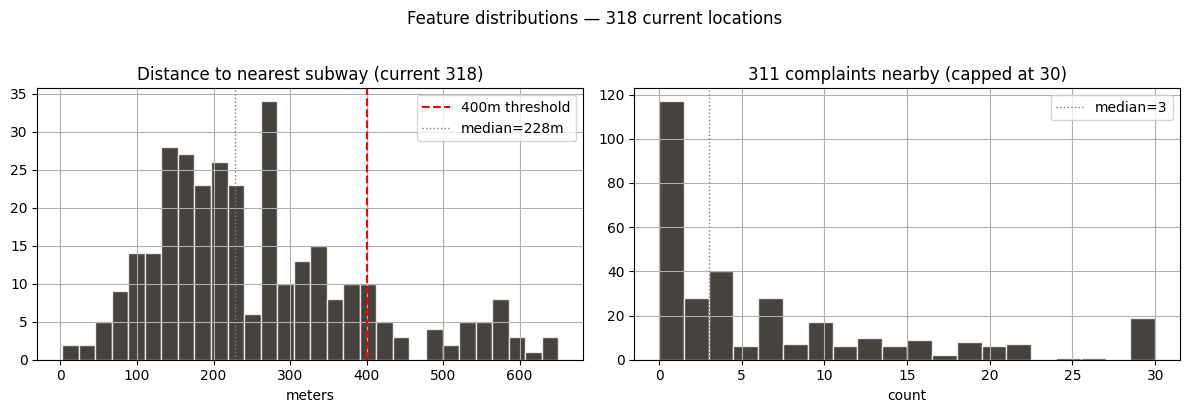

In [16]:
# Feature distributions — continuous variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

curr_df['dist_subway_m'].hist(bins=30, ax=axes[0], color='#18140e', alpha=0.8, edgecolor='white')
axes[0].axvline(400, color='red', lw=1.5, ls='--', label='400m threshold')
axes[0].axvline(curr_df['dist_subway_m'].median(), color='gray', lw=1, ls=':', label=f"median={curr_df['dist_subway_m'].median():.0f}m")
axes[0].set_title('Distance to nearest subway (current 318)')
axes[0].set_xlabel('meters'); axes[0].legend()

curr_df['complaints_clean'].hist(bins=20, ax=axes[1], color='#18140e', alpha=0.8, edgecolor='white')
axes[1].axvline(curr_df['complaints_clean'].median(), color='gray', lw=1, ls=':', label=f"median={curr_df['complaints_clean'].median():.0f}")
axes[1].set_title('311 complaints nearby (capped at 30)')
axes[1].set_xlabel('count'); axes[1].legend()

plt.suptitle('Feature distributions — 318 current locations', y=1.02)
plt.tight_layout()
plt.show()

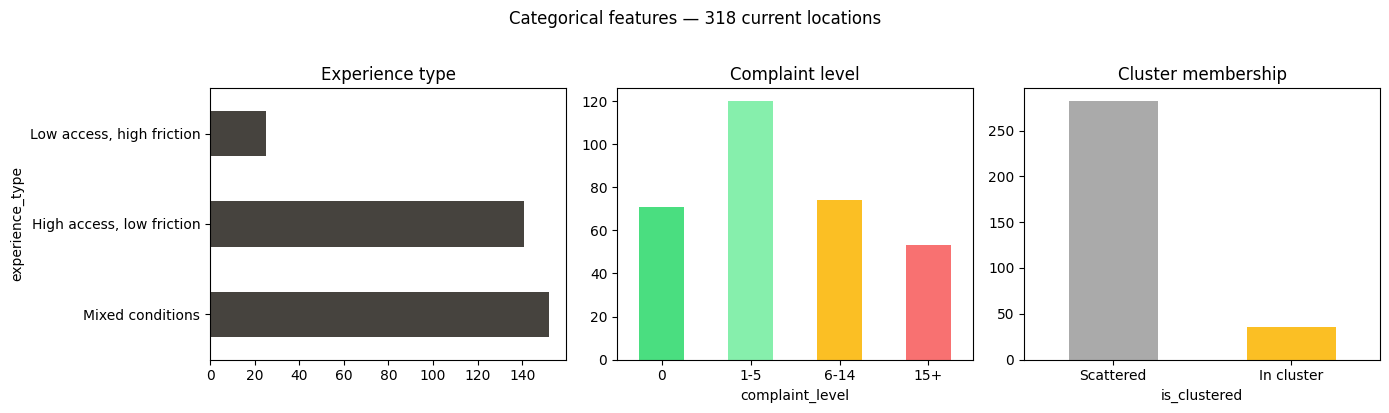

In [17]:
# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

curr_df['experience_type'].value_counts().plot(kind='barh', ax=axes[0], color='#18140e', alpha=0.8)
axes[0].set_title('Experience type')

curr_df['complaint_level'].value_counts().reindex(['0','1-5','6-14','15+']).plot(
    kind='bar', ax=axes[1], color=['#4ade80','#86efac','#fbbf24','#f87171'])
axes[1].set_title('Complaint level')
axes[1].tick_params(axis='x', rotation=0)

curr_df['is_clustered'].value_counts().plot(kind='bar', ax=axes[2], color=['#aaaaaa','#fbbf24'])
axes[2].set_xticklabels(['Scattered','In cluster'], rotation=0)
axes[2].set_title('Cluster membership')

plt.suptitle('Categorical features — 318 current locations', y=1.02)
plt.tight_layout()
plt.show()

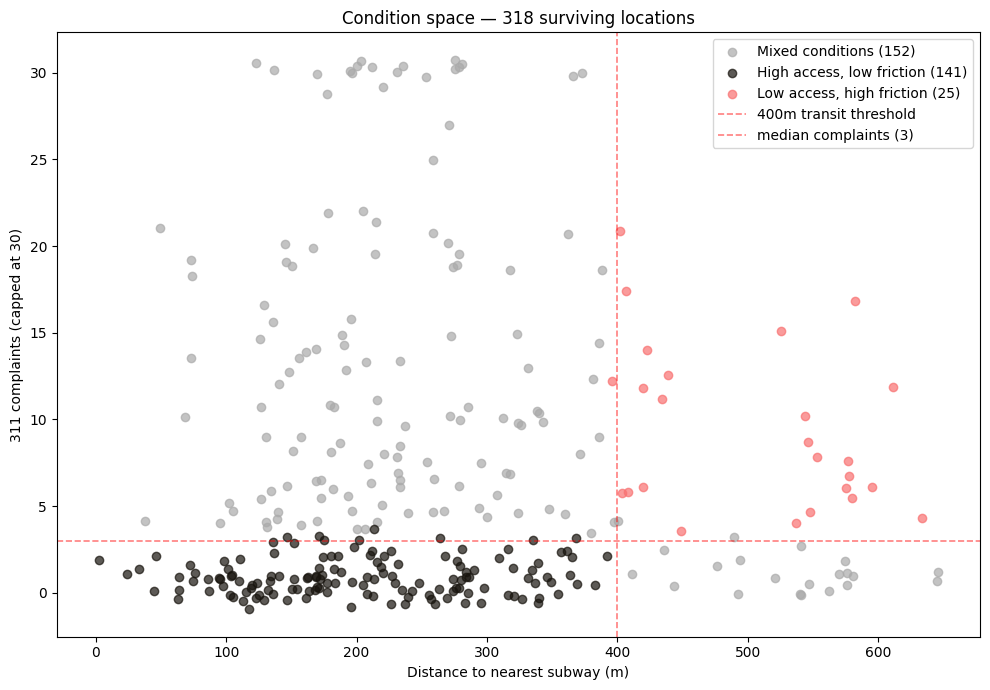

Near transit + low friction: 141/318 (44%) — 'survival zone'


In [18]:
# Condition space scatter — access vs friction
fig, ax = plt.subplots(figsize=(10, 7))

color_map = {
    'High access, low friction': '#18140e',
    'Mixed conditions':          '#aaaaaa',
    'Low access, high friction': '#f87171',
}

rng = np.random.default_rng(42)
for exp_type in ['Mixed conditions', 'High access, low friction', 'Low access, high friction']:
    sub = curr_df[curr_df['experience_type'] == exp_type]
    x = sub['dist_subway_m'] + rng.normal(0, 7, len(sub))
    y = sub['complaints_clean'] + rng.normal(0, 0.4, len(sub))
    ax.scatter(x, y, c=color_map[exp_type], alpha=0.7, label=f"{exp_type} ({len(sub)})")

ax.axvline(400, color='red', lw=1.2, ls='--', alpha=0.5, label='400m transit threshold')
ax.axhline(3,   color='red', lw=1.2, ls='--', alpha=0.5, label='median complaints (3)')
ax.set_xlabel('Distance to nearest subway (m)')
ax.set_ylabel('311 complaints (capped at 30)')
ax.set_title('Condition space — 318 surviving locations')
ax.legend()
plt.tight_layout()
plt.show()

n_bl = len(curr_df[(curr_df['dist_subway_m'] <= 400) & (curr_df['complaints_clean'] <= 3)])
print(f"Near transit + low friction: {n_bl}/318 ({n_bl/318*100:.0f}%) — 'survival zone'")

---
## 2b. EDA — ML dataset (historic + current)

Using the combined dataset built in Section 1.

> **Note on complaint data:** Complaint data is available only for current locations (survived=1).
> It is excluded from the ML model due to unavailability for historic locations.

ML dataset shape: (4977, 8)

Class distribution:
survived
0    4659
1     318
Name: count, dtype: int64


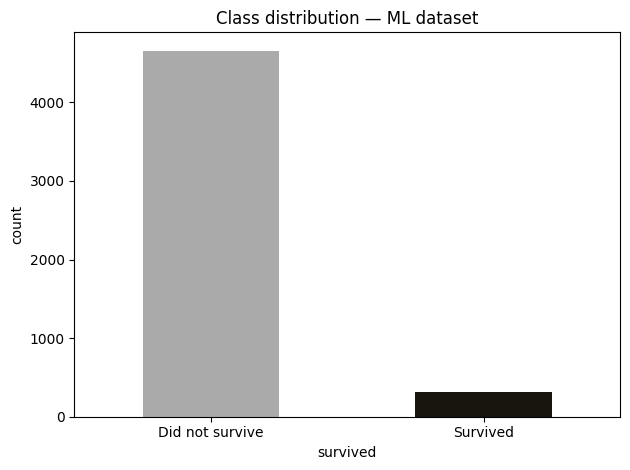

→ Class imbalance 1:14
→ Will address with class_weight="balanced" in Milestone 03 modeling


In [19]:
print(f'ML dataset shape: {dining_df.shape}')
print(f'\nClass distribution:')
print(dining_df['survived'].value_counts())

dining_df['survived'].value_counts().plot(kind='bar', color=['#aaaaaa','#18140e'])
plt.title('Class distribution — ML dataset')
plt.xticks([0, 1], ['Did not survive', 'Survived'], rotation=0)
plt.ylabel('count')
plt.tight_layout()
plt.show()

print(f'→ Class imbalance 1:{dining_df[dining_df.survived==0].shape[0] // dining_df[dining_df.survived==1].shape[0]}')
print(f'→ Will address with class_weight="balanced" in Milestone 03 modeling')

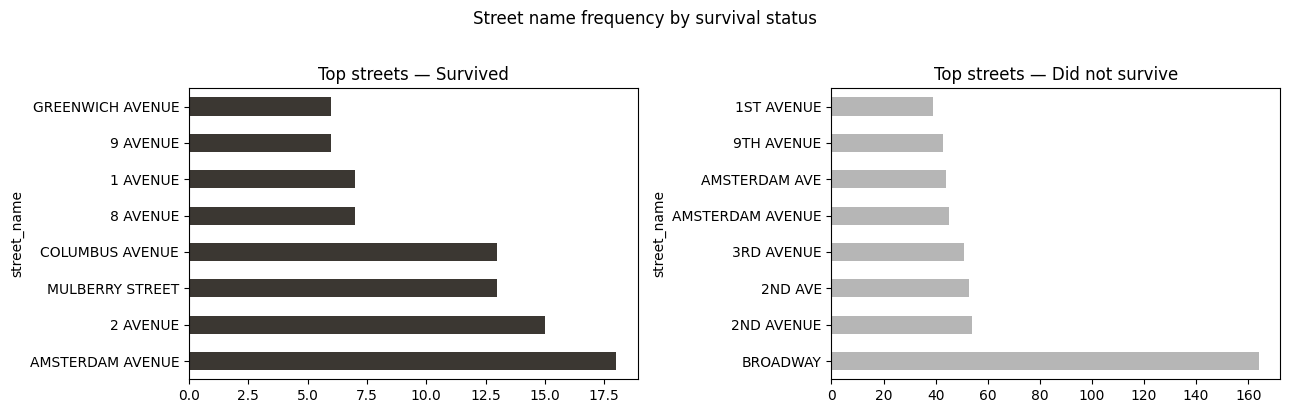

In [20]:
# Top streets — survived vs not survived
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dining_df[dining_df.survived==1]['street_name'].value_counts().head(8).plot(
    kind='barh', ax=axes[0], color='#18140e', alpha=0.85)
axes[0].set_title('Top streets — Survived')

dining_df[dining_df.survived==0]['street_name'].value_counts().head(8).plot(
    kind='barh', ax=axes[1], color='#aaaaaa', alpha=0.85)
axes[1].set_title('Top streets — Did not survive')

plt.suptitle('Street name frequency by survival status', y=1.02)
plt.tight_layout()
plt.show()

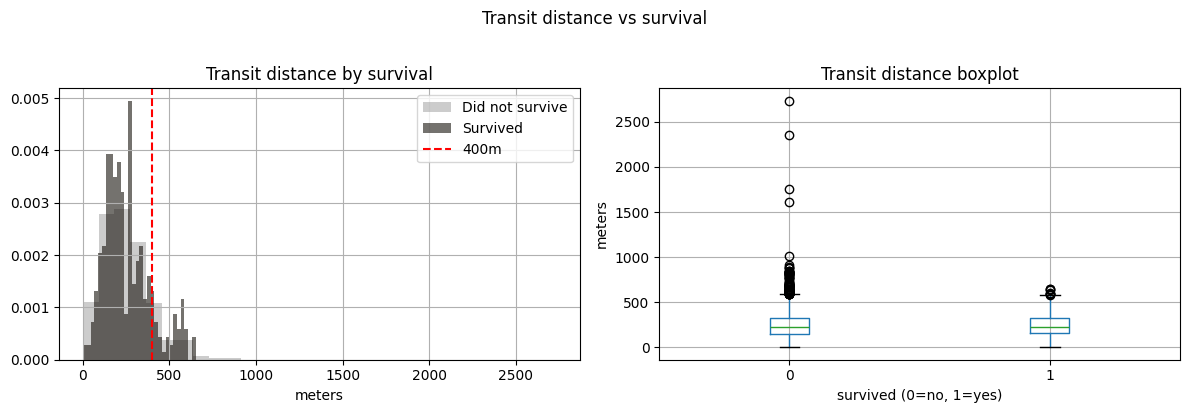

Median dist — survived: 228m  |  not survived: 231m


In [21]:
# Transit distance: survived vs not survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, group in dining_df.groupby('survived'):
    name  = 'Survived' if label == 1 else 'Did not survive'
    color = '#18140e'  if label == 1 else '#aaaaaa'
    group['dist_subway_m'].hist(bins=30, ax=axes[0], alpha=0.6, label=name, color=color, density=True)
axes[0].axvline(400, color='red', lw=1.5, ls='--', label='400m')
axes[0].set_title('Transit distance by survival')
axes[0].set_xlabel('meters')
axes[0].legend()

dining_df.boxplot(column='dist_subway_m', by='survived', ax=axes[1])
axes[1].set_title('Transit distance boxplot')
axes[1].set_xlabel('survived (0=no, 1=yes)')
axes[1].set_ylabel('meters')

plt.suptitle('Transit distance vs survival', y=1.02)
plt.tight_layout()
plt.show()

print(f"Median dist — survived: {dining_df[dining_df.survived==1]['dist_subway_m'].median():.0f}m  |  not survived: {dining_df[dining_df.survived==0]['dist_subway_m'].median():.0f}m")

### Interpretation: Transit Distance

There is a clear shift toward shorter distances among surviving locations. While not deterministic, this indicates that access to transit is one of the conditions associated with survival.

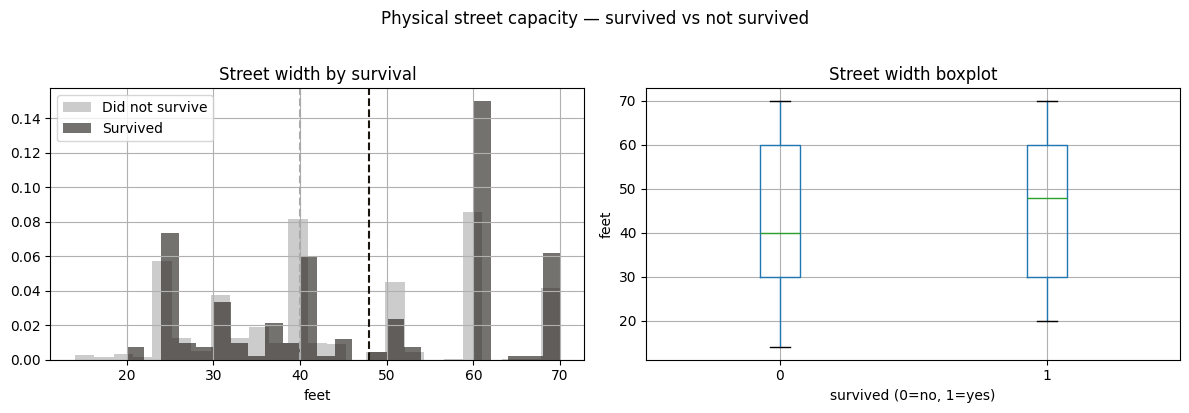

Median streetwidth — survived: 48ft  |  not survived: 40ft


In [22]:
# Street width: survived vs not survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, group in dining_df.groupby('survived'):
    name  = 'Survived' if label == 1 else 'Did not survive'
    color = '#18140e'  if label == 1 else '#aaaaaa'
    group['streetwidth'].hist(bins=25, ax=axes[0], alpha=0.6, label=name, color=color, density=True)
axes[0].axvline(dining_df[dining_df.survived==1]['streetwidth'].median(), color='#18140e', lw=1.5, ls='--')
axes[0].axvline(dining_df[dining_df.survived==0]['streetwidth'].median(), color='#aaaaaa', lw=1.5, ls='--')
axes[0].set_title('Street width by survival')
axes[0].set_xlabel('feet')
axes[0].legend()

dining_df.boxplot(column='streetwidth', by='survived', ax=axes[1])
axes[1].set_title('Street width boxplot')
axes[1].set_xlabel('survived (0=no, 1=yes)')
axes[1].set_ylabel('feet')

plt.suptitle('Physical street capacity — survived vs not survived', y=1.02)
plt.tight_layout()
plt.show()

print(f"Median streetwidth — survived: {dining_df[dining_df.survived==1]['streetwidth'].median():.0f}ft  |  not survived: {dining_df[dining_df.survived==0]['streetwidth'].median():.0f}ft")

### Interpretation: Street Width

Surviving locations tend to be on wider streets. This indicates that physical street capacity is one of the conditions associated with where outdoor dining remains.

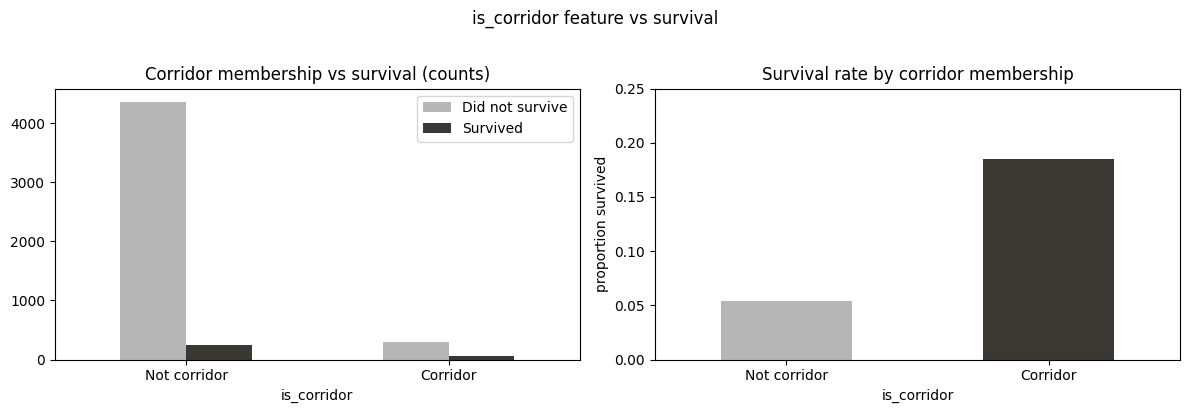

Survival rate:
  Non-corridor: 0.054
  Corridor:     0.185


In [23]:
# Corridor feature: survival rate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count by corridor flag
corridor_counts = dining_df.groupby(['is_corridor', 'survived']).size().unstack(fill_value=0)
corridor_counts.plot(kind='bar', ax=axes[0], color=['#aaaaaa', '#18140e'], alpha=0.85)
axes[0].set_xticklabels(['Not corridor', 'Corridor'], rotation=0)
axes[0].set_title('Corridor membership vs survival (counts)')
axes[0].legend(['Did not survive', 'Survived'])

# Survival rate by corridor flag
survival_rate = dining_df.groupby('is_corridor')['survived'].mean()
survival_rate.plot(kind='bar', ax=axes[1], color=['#aaaaaa', '#18140e'], alpha=0.85)
axes[1].set_xticklabels(['Not corridor', 'Corridor'], rotation=0)
axes[1].set_title('Survival rate by corridor membership')
axes[1].set_ylabel('proportion survived')
axes[1].set_ylim(0, 0.25)

plt.suptitle('is_corridor feature vs survival', y=1.02)
plt.tight_layout()
plt.show()

print('Survival rate:')
print(f'  Non-corridor: {dining_df[dining_df.is_corridor==0]["survived"].mean():.3f}')
print(f'  Corridor:     {dining_df[dining_df.is_corridor==1]["survived"].mean():.3f}')

---
## 3. PCA — Does it make sense to visualize feature shapes?

PCA on the 3 ML features (`dist_subway_m`, `is_near_transit`, `is_corridor`).  
Features are scaled before PCA since `dist_subway_m` (0–650m) would dominate binary features otherwise.

PCA is used to explore whether these spatial features create any separable structure between surviving and non-surviving locations.

In [24]:
FEATURES = ['dist_subway_m', 'is_near_transit', 'is_corridor']
OUTCOME  = 'survived'

model_df = dining_df[FEATURES + [OUTCOME]].dropna()
print(f'Dataset for PCA: {len(model_df):,} rows, {len(FEATURES)} features')
print(f'Missing values: {model_df.isnull().sum().sum()}')

Dataset for PCA: 4,977 rows, 3 features
Missing values: 0


In [25]:
# Scale features for PCA only
# Note: dist_subway_m ranges 0–650m while binary features are 0/1 — scaling needed for PCA
scaler_pca = StandardScaler()
features_scaled = scaler_pca.fit_transform(model_df[FEATURES])

print('Feature means (before scaling):', model_df[FEATURES].mean().round(2).to_dict())
print('Feature stds  (before scaling):', model_df[FEATURES].std().round(2).to_dict())
print('\n→ StandardScaler applied for PCA only.')
print('  For tree-based models (Random Forest), scaling is not required.')
print('  For Logistic Regression (Milestone 03), scaler will be fit on train set only.')

Feature means (before scaling): {'dist_subway_m': 253.02, 'is_near_transit': 0.87, 'is_corridor': 0.07}
Feature stds  (before scaling): {'dist_subway_m': 149.48, 'is_near_transit': 0.34, 'is_corridor': 0.26}

→ StandardScaler applied for PCA only.
  For tree-based models (Random Forest), scaling is not required.
  For Logistic Regression (Milestone 03), scaler will be fit on train set only.


Explained variance: PC1=0.57, PC2=0.33
Total explained:    0.90


/Users/hoon/miniconda3/envs/5020/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/hoon/miniconda3/envs/5020/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/hoon/miniconda3/envs/5020/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


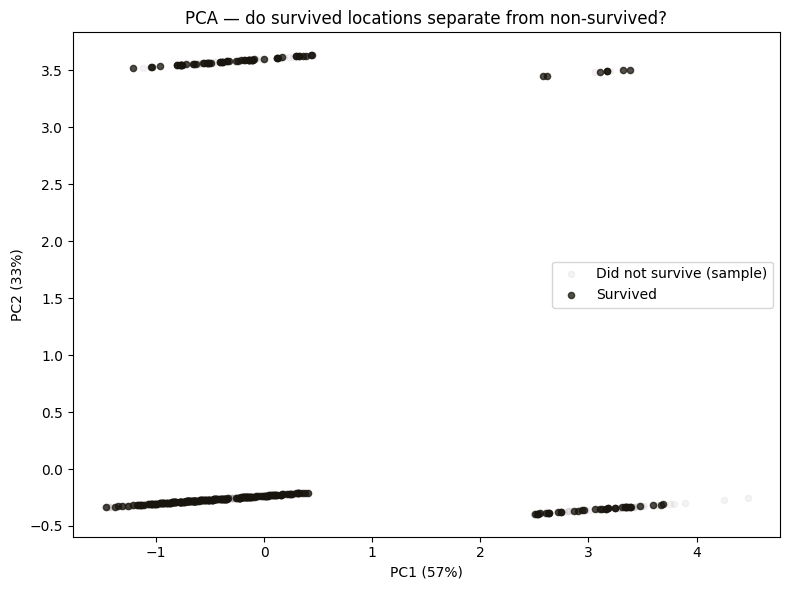

In [26]:
pca = PCA(n_components=2)
pca_array = pca.fit_transform(features_scaled)
pca_df = pd.DataFrame(pca_array, columns=['PC1', 'PC2'])
pca_df['survived'] = model_df[OUTCOME].values

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.2f}, PC2={pca.explained_variance_ratio_[1]:.2f}')
print(f'Total explained:    {pca.explained_variance_ratio_.sum():.2f}')

fig, ax = plt.subplots(figsize=(8, 6))
for label, group in pca_df.groupby('survived'):
    sample = group.sample(min(500, len(group)), random_state=42)
    name  = 'Survived' if label == 1 else 'Did not survive (sample)'
    color = '#18140e'  if label == 1 else '#aaaaaa'
    alpha = 0.75       if label == 1 else 0.12
    ax.scatter(sample['PC1'], sample['PC2'], c=color, alpha=alpha, s=20, label=name)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('PCA — do survived locations separate from non-survived?')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# PCA loadings — what does each component represent?
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
).round(3)

print('PCA Loadings (feature contribution per component):')
display(loadings_df)

PCA Loadings (feature contribution per component):


,PC1,PC2
dist_subway_m,0.707,0.049
is_near_transit,-0.707,0.063
is_corridor,0.010,0.997


### Interpretation: PCA Loadings

PC1 is dominated by `dist_subway_m` and `is_near_transit` — these two features are highly correlated. PC2 likely captures `is_corridor` independently, suggesting that street corridor membership operates along a different axis than transit access.

---
## 4. Summary

### Dataset

| | Count |
|---|---|
| Historic locations (survived=0) | 4,659 |
| Current locations (survived=1) | 318 |
| Class imbalance | 1:14 |
| Features | `dist_subway_m`, `is_near_transit`, `is_corridor`, `streetwidth` |
| Outcome | `survived` (binary) |

### Findings

| Variable | Direction | Notes |
|----------|-----------|-------|
| `dist_subway_m` | shorter distance → higher survival tendency | strongest signal |
| `is_near_transit` | correlated with `dist_subway_m` | may drop in Milestone 03 |
| `is_corridor` | corridor → higher survival tendency | street clustering effect |
| `streetwidth` | wider streets → associated with survival | physical street conditions |

These patterns suggest that survival is associated with a combination of access, street structure, and physical capacity.

### Limitations

1. **Complaints unavailable for historic data** — friction variable excluded from ML model, used in Section 2a only
2. **Class imbalance 1:14** — will address with `class_weight='balanced'` in Milestone 03
3. **Correlation ≠ causation** — this is exploratory, not causal
4. **Street name normalization** — historic data uses street names only (e.g. `2ND AVENUE`), current data uses full addresses. Normalization was applied but edge cases may remain.
5. **Street width coverage (~52%)** — Matches were made using street name and partial matching. The coverage reflects geometry mismatch between point data (dining locations) and line data (street segments), not data quality issues. This is a structural limitation of spatial joining and indicates that the streetwidth analysis represents a subset of locations—specifically, those with available street segment data. More precise spatial methods (e.g., nearest street segment within 20m buffer) could improve coverage in future work.

### Next steps (Milestone 03)

- Logistic Regression + Random Forest with `class_weight='balanced'`
- `StandardScaler` fit on train set only (prevent data leakage)
- Add 311 rodent complaint data as friction proxy
- Cross-validation and hyperparameter tuning